# Milestone 2

## Cleaning/Formatting Flat File Source

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
players = pd.read_csv("G:/My Drive/College/Caitie/DSC540-T301/volleybox_women_players.csv")

Perform at least 5 data transformation and/or cleansing steps to your flat file data.

In [7]:
players.head()

,Id,Name,Nickname,Maiden name,Birthdate,Nationality,Position,Dominant hand,Height (cm),Weight (kg),...,Followers,Player ranking,Coach ranking,Registered,Views,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


In [9]:
orig_len = len(players)
orig_len

78693

### First Transformation

In [12]:
# Identify any duplicates for key or name
print("ID is duplicated: {}".format(any(players.Id.duplicated())))
print("Name is duplicated: {}".format(any(players.Name.duplicated())))

ID is duplicated: False
Name is duplicated: True


In [14]:
# Remove duplicated players based on name and birthday
player_dedup = players.drop_duplicates(subset=['Name', 'Birthdate'],keep='first')
player_dedup.head()

,Id,Name,Nickname,Maiden name,Birthdate,Nationality,Position,Dominant hand,Height (cm),Weight (kg),...,Followers,Player ranking,Coach ranking,Registered,Views,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,NaN,NaN,Italy,Universal,NaN,NaN,NaN,...,NaN,NaN,NaN,No,6,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


In [16]:
dedup_len = len(player_dedup)
dedup_len

78549

### Second Transformation

In [19]:
# Reduce dataset to remove retired players based on age > 50
#  Left NULL values in as some are current players
player_age = player_dedup[(player_dedup['Birthdate'] >= '1975-01-01') | (player_dedup['Birthdate'].isnull())]
print(player_age.head())

        Id                 Name Nickname Maiden name Birthdate Nationality  \
0  p178623  Giada Maria Falsone      NaN         NaN       NaN       Italy   
1  p178618     Giorgia Polimeni      NaN         NaN       NaN       Italy   
2  p178616        Silvia Simone      NaN         NaN       NaN       Italy   
3  p178614        Martina Mazza      NaN         NaN       NaN       Italy   
4  p178613  Sophia Letizia Foti      NaN         NaN       NaN       Italy   

    Position Dominant hand  Height (cm)  Weight (kg)  ...  Followers  \
0  Universal           NaN          NaN          NaN  ...        NaN   
1  Universal           NaN          NaN          NaN  ...        NaN   
2  Universal           NaN          NaN          NaN  ...        NaN   
3  Universal           NaN          NaN          NaN  ...        NaN   
4  Universal           NaN          NaN          NaN  ...        NaN   

   Player ranking Coach ranking Registered Views Last activity  \
0             NaN           NaN 

In [21]:
age_len = len(player_age)
age_len

76573

### Third Transformation

In [24]:
# Reorder of columns in data set to put key ones first
player_reorder = player_age[['Id', 'Name', 'Birthdate', 'Nationality', 'Position', 'Dominant hand', 'Height (cm)', 'Weight (kg)', 'Season', 
'Club', 'ClubId', 'LeagueCountry', 'ActivePlayer', 'Clubs', 'Teammates', 'Tournaments', 'Matches', 'Awards', 
'Ranking', 'Ranking in 2023', 'Player ranking', 'Coach ranking', 'Registered', 'Views', 'Nickname', 'Maiden name', 
'Spike (cm)', 'Block (cm)', 'Url', 'Image', 'ClubUrl', 'ClubLogo', 'LeagueCountryFlag', 'Agent', 'Top100', 'Top200', 
'Top500', 'Twitter', 'Facebook', 'Instagram', 'Youtube', 'Linkedin', 'Website', 'Timeline', 'Followers', 'Last activity', 
'Added by', 'User', 'Recommendations', 'Partners']]
player_reorder.head()

,Id,Name,Birthdate,Nationality,Position,Dominant hand,Height (cm),Weight (kg),Season,Club,...,Youtube,Linkedin,Website,Timeline,Followers,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


### Fourth Transformation

In [27]:
# Correct Players Height/Weight

In [29]:
# Alice Gillier's height should be 180 not 280
player_reorder.loc[player_reorder['Name'] == 'Alice Gillier', 'Height (cm)'] = 180

In [31]:
# Null out weight above 140 kg
player_reorder.loc[player_reorder['Weight (kg)'] >= 140] = np.nan
player_reorder['Weight (kg)'].unique()

array([ nan,  68.,  55.,  65.,  58.,  50.,  60.,  62.,  66.,  61.,  70.,
        67.,  80.,  75.,  54.,  63.,  49.,  56.,  59.,  64.,  57.,  72.,
        69.,  53.,  51.,  96.,  78.,  85.,  79.,  74.,  52.,  89.,  71.,
        46.,  86.,  87.,  48.,  97.,  95.,  76.,  73.,  77.,  83.,  47.,
        81.,  84.,  82.,  44.,  45.,  90.,  38.,  43.,  92.,  91.,  88.,
        98., 110., 104.,  93., 105.,  99., 102.,  94., 100., 111.,  40.,
        42.,  41., 120.,  39.,  35.])

### Fifth Transformation

In [34]:
# Convert Height from centimeters to inches
player_reorder['Height (cm)'] = player_reorder['Height (cm)'] * 0.393701
player_reorder.loc[:,'Height (cm)']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
78687    68.897675
78689    66.141768
78690    71.259881
78691          NaN
78692          NaN
Name: Height (cm), Length: 76573, dtype: float64

In [36]:
# Rename field to indicate correct measurement type
player_reorder = player_reorder.rename(columns={'Height (cm)': 'Height (in)'})
player_reorder.head()

,Id,Name,Birthdate,Nationality,Position,Dominant hand,Height (in),Weight (kg),Season,Club,...,Youtube,Linkedin,Website,Timeline,Followers,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


### Sixth Transformation

In [38]:
# Convert Weight from kilograms to pounds
player_reorder['Weight (kg)'] = player_reorder['Weight (kg)'] * 2.20462
player_reorder.loc[:,'Weight (kg)']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
78687    156.52802
78689    130.07258
78690    147.70954
78691          NaN
78692          NaN
Name: Weight (kg), Length: 76573, dtype: float64

In [40]:
# Rename field to indicate correct measurement type
player_reorder = player_reorder.rename(columns={'Weight (kg)': 'Weight (lb)'})
player_reorder.head()

,Id,Name,Birthdate,Nationality,Position,Dominant hand,Height (in),Weight (lb),Season,Club,...,Youtube,Linkedin,Website,Timeline,Followers,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,...,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


### Seventh Transformation

In [43]:
# Remove "-" from Position Field
player_reorder['Position'] = player_reorder['Position'].replace({'-': ' ', }) 
player_reorder['Position'].unique()

array(['Universal', 'Middle-blocker', 'Setter', 'Libero',
       'Outside Hitter', 'Opposite', nan], dtype=object)

In [45]:
# Show Final Table
pd.set_option('display.max_columns', None)
player_reorder.head()

,Id,Name,Birthdate,Nationality,Position,Dominant hand,Height (in),Weight (lb),Season,Club,ClubId,LeagueCountry,ActivePlayer,Clubs,Teammates,Tournaments,Matches,Awards,Ranking,Ranking in 2023,Player ranking,Coach ranking,Registered,Views,Nickname,Maiden name,Spike (cm),Block (cm),Url,Image,ClubUrl,ClubLogo,LeagueCountryFlag,Agent,Top100,Top200,Top500,Twitter,Facebook,Instagram,Youtube,Linkedin,Website,Timeline,Followers,Last activity,Added by,User,Recommendations,Partners
0,p178623,Giada Maria Falsone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,t20329,Italy,Yes,1.0,16.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,No,6.0,NaN,NaN,NaN,NaN,https://women.volleybox.net/giada-maria-falson...,https://volleybox.net/media/upload/players/def...,https://women.volleybox.net/polisportiva-elio-...,https://volleybox.net/media/upload/teams/16938...,https://volleybox.net/media/img/flags/IT.png,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
1,p178618,Giorgia Polimeni,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,t20329,Italy,Yes,1.0,16.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,No,6.0,NaN,NaN,NaN,NaN,https://women.volleybox.net/giorgia-polimeni-p...,https://volleybox.net/media/upload/players/def...,https://women.volleybox.net/polisportiva-elio-...,https://volleybox.net/media/upload/teams/16938...,https://volleybox.net/media/img/flags/IT.png,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
2,p178616,Silvia Simone,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,t20329,Italy,Yes,1.0,16.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,No,6.0,NaN,NaN,NaN,NaN,https://women.volleybox.net/silvia-simone-p178616,https://volleybox.net/media/upload/players/def...,https://women.volleybox.net/polisportiva-elio-...,https://volleybox.net/media/upload/teams/16938...,https://volleybox.net/media/img/flags/IT.png,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
3,p178614,Martina Mazza,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,t20329,Italy,Yes,1.0,16.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,No,6.0,NaN,NaN,NaN,NaN,https://women.volleybox.net/martina-mazza-p178614,https://volleybox.net/media/upload/players/def...,https://women.volleybox.net/polisportiva-elio-...,https://volleybox.net/media/upload/teams/16938...,https://volleybox.net/media/img/flags/IT.png,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN
4,p178613,Sophia Letizia Foti,NaN,Italy,Universal,NaN,NaN,NaN,2023/24 - 2023/24,Polisportiva Elio Sozzi Reggio Calabria,t20329,Italy,Yes,1.0,16.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,No,6.0,NaN,NaN,NaN,NaN,https://women.volleybox.net/sophia-letizia-fot...,https://volleybox.net/media/upload/players/def...,https://women.volleybox.net/polisportiva-elio-...,https://volleybox.net/media/upload/teams/16938...,https://volleybox.net/media/img/flags/IT.png,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Mattia Mario Guido Caputo,NaN,NaN,NaN


### Eighth Transformation

In [48]:
# Spliting player name into first and last name
player_reorder['FName'] = player_reorder['Name'].str.split().str[0]
player_reorder['Lname'] = player_reorder['Name'].str.split().str[-1]
player_reorder['first_name'] = player_reorder['Name'].str.split().str[0]
player_reorder['last_name'] = player_reorder['Name'].str.split().str[1:].str.join(' ')
player_reorder['middle_name'] = player_reorder['last_name'].str.split().str[0]
player_reorder['last_name_final'] = player_reorder['last_name'].str.split().str[1:].str.join(' ')
player_reorder['last_name_final'] = player_reorder.apply(lambda x: x['middle_name'] if x['last_name_final']=='' else x['last_name_final'], axis=1)
player_reorder['middle_name'] = player_reorder.apply(lambda x: x['Lname'] if x['last_name_final']==x['middle_name'] else x['middle_name'], axis=1)
player_reorder['first_initial'] = player_reorder.first_name.str[0]

In [50]:
# Drop extra name fields
del player_reorder['FName']
del player_reorder['Lname']

In [52]:
print(player_reorder.head(40))

         Id                      Name   Birthdate Nationality        Position  \
0   p178623       Giada Maria Falsone         NaN       Italy       Universal   
1   p178618          Giorgia Polimeni         NaN       Italy       Universal   
2   p178616             Silvia Simone         NaN       Italy       Universal   
3   p178614             Martina Mazza         NaN       Italy       Universal   
4   p178613       Sophia Letizia Foti         NaN       Italy       Universal   
5   p178612            Martina Caruso         NaN       Italy       Universal   
6   p178611              Reina Hamano  1976-07-19       Japan  Middle-blocker   
7   p178610             Erika Furfaro         NaN       Italy       Universal   
8   p178609           Lara Battimelli         NaN       Italy       Universal   
9   p178604          Irene Pizzarello  2000-01-01       Italy          Setter   
10  p178603             Giada Calluso  2008-01-01       Italy       Universal   
11  p178602          Giorgia

There were very few changes to the data itself.  The height and weight fields were converted into standard from metric.\
The one height outlier was looked up and changed.  The weight ouliers were changed to NaN.\
These conversions provide very little risk as the outliers were removed and typically weight does not have a major\
impact to player performance.  Since Kaggle was my source for data and users can upload or correct the data on Kaggle,\
there is the chance that data could be entered incorrectly.  I sampled a well known professional volleyball player \
from Nebraska (Jordan Larson) and the data for her was accurate.  Finding a way to get player statistics direct from \
the professional leagues would be a way to make the data more credible, but may take more work if there isn't a \
unified dataset provided by the leagues because you'd have to find stats on each team.

# Milestone 3

## Cleaning and Formatting Website Data

In [57]:
# Load Necessary Libaries
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [59]:
# Retrieving Data
player_site = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6620/players/')
player_site

[                            No.                  Player Name  \
 0                             2                      Poulter   
 1                             3                   A. Skinner   
 2                             4                 Wong-Orantes   
 3                             7                      Carlini   
 4                            10                       Larson   
 5                            11                        Drews   
 6                            12                     Thompson   
 7                            15                   Washington   
 8                            16                       Rettke   
 9                            22                      Plummer   
 10                           23                         Cook   
 11                           24                       Ogbogu   
 12                          NaN                 Karch Kiraly   
 13          Reserve player (AP)          Reserve player (AP)   
 14                      

In [61]:
#Determinen number of tables
print(f'Total tables: {len(player_site)}')

Total tables: 1


In [63]:
#Move HTML table into data frame
usa_players = player_site[0]
usa_players

,No.,Player Name,Position
0,2,Poulter,S
1,3,A. Skinner,OH
2,4,Wong-Orantes,L
3,7,Carlini,S
4,10,Larson,OH
5,11,Drews,O
6,12,Thompson,O
7,15,Washington,MB
8,16,Rettke,MB
9,22,Plummer,OH


In [65]:
#Step 1:  Add column for team name
usa_players.insert(0, 'Name', 'USA')
usa_players

,Name,No.,Player Name,Position
0,USA,2,Poulter,S
1,USA,3,A. Skinner,OH
2,USA,4,Wong-Orantes,L
3,USA,7,Carlini,S
4,USA,10,Larson,OH
5,USA,11,Drews,O
6,USA,12,Thompson,O
7,USA,15,Washington,MB
8,USA,16,Rettke,MB
9,USA,22,Plummer,OH


In [67]:
#Step 2:  Remove coach and reserve players
index = usa_players[usa_players['Position'] == 'COACH'].index[0]
usa_filtered = usa_players.loc[:index-1]
usa_filtered

,Name,No.,Player Name,Position
0,USA,2,Poulter,S
1,USA,3,A. Skinner,OH
2,USA,4,Wong-Orantes,L
3,USA,7,Carlini,S
4,USA,10,Larson,OH
5,USA,11,Drews,O
6,USA,12,Thompson,O
7,USA,15,Washington,MB
8,USA,16,Rettke,MB
9,USA,22,Plummer,OH


In [69]:
#Step 3:  Replace column names
usa_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
usa_filtered

,Team,JerseyNumber,Name,Position
0,USA,2,Poulter,S
1,USA,3,A. Skinner,OH
2,USA,4,Wong-Orantes,L
3,USA,7,Carlini,S
4,USA,10,Larson,OH
5,USA,11,Drews,O
6,USA,12,Thompson,O
7,USA,15,Washington,MB
8,USA,16,Rettke,MB
9,USA,22,Plummer,OH


In [71]:
#Step 4:  Replace position acronyms with full name
def player_position(x):
    if any('L' in str(item) for item in x):
        return 'Libero'
    elif any('S' in str(item) for item in x):
        return 'Setter'
    elif any('MB' for item in x):
        return 'Middle-Blocker'
    elif any('OH' in str(item) for item in x):
        return 'Outside Hitter'
    elif any('O' in str(item) for item in x):
        return 'Opposite'
    else:
        return ['Position']

usa_filtered['Position'] = usa_filtered['Position'].apply(player_position)
usa_filtered

C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\2031534157.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usa_filtered['Position'] = usa_filtered['Position'].apply(player_position)


,Team,JerseyNumber,Name,Position
0,USA,2,Poulter,Setter
1,USA,3,A. Skinner,Middle-Blocker
2,USA,4,Wong-Orantes,Libero
3,USA,7,Carlini,Setter
4,USA,10,Larson,Middle-Blocker
5,USA,11,Drews,Middle-Blocker
6,USA,12,Thompson,Middle-Blocker
7,USA,15,Washington,Middle-Blocker
8,USA,16,Rettke,Middle-Blocker
9,USA,22,Plummer,Middle-Blocker


In [73]:
# Repeat for other teams
player_site1 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6619/players/')
brazil_players = player_site1[0]
brazil_players.insert(0, 'Name', 'BRA')
index1 = brazil_players[brazil_players['Position'] == 'COACH'].index[0]
brazil_filtered = brazil_players.loc[:index1-1]
brazil_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
brazil_filtered['Position'] = brazil_filtered['Position'].apply(player_position)

player_site2 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/7028/players/')
china_players = player_site2[0]
china_players.insert(0, 'Name', 'CHI')
index2 = china_players[china_players['Position'] == 'COACH'].index[0]
china_filtered = china_players.loc[:index2-1]
china_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
china_filtered['Position'] = china_filtered['Position'].apply(player_position)

player_site3 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6616/players/')
domrep_players = player_site3[0]
domrep_players.insert(0, 'Name', 'DOM')
index3 = domrep_players[domrep_players['Position'] == 'COACH'].index[0]
domrep_filtered = domrep_players.loc[:index3-1]
domrep_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
domrep_filtered['Position'] = domrep_filtered['Position'].apply(player_position)

player_site4 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6615/players/')
france_players = player_site4[0]
france_players.insert(0, 'Name', 'FRA')
index4 = france_players[france_players['Position'] == 'COACH'].index[0]
france_filtered = france_players.loc[:index4-1]
france_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
france_filtered['Position'] = france_filtered['Position'].apply(player_position)

player_site5 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/7024/players/')
italy_players = player_site5[0]
italy_players.insert(0, 'Name', 'ITA')
index5 = italy_players[italy_players['Position'] == 'COACH'].index[0]
italy_filtered = italy_players.loc[:index5-1]
italy_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
italy_filtered['Position'] = italy_filtered['Position'].apply(player_position)

player_site6 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/7026/players/')
japan_players = player_site6[0]
japan_players.insert(0, 'Name', 'JAP')
index6 = japan_players[japan_players['Position'] == 'COACH'].index[0]
japan_filtered = japan_players.loc[:index6-1]
japan_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
japan_filtered['Position'] = japan_filtered['Position'].apply(player_position)

player_site7 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/7027/players/')
kenya_players = player_site7[0]
kenya_players.insert(0, 'Name', 'KEN')
index7 = kenya_players[kenya_players['Position'] == 'COACH'].index[0]
kenya_filtered = kenya_players.loc[:index7-1]
kenya_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
kenya_filtered['Position'] = kenya_filtered['Position'].apply(player_position)

player_site8 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/7023/players/')
neth_players = player_site8[0]
neth_players.insert(0, 'Name', 'NET')
index8 = neth_players[neth_players['Position'] == 'COACH'].index[0]
neth_filtered = neth_players.loc[:index8-1]
neth_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
neth_filtered['Position'] = neth_filtered['Position'].apply(player_position)

player_site9 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6612/players/')
poland_players = player_site9[0]
poland_players.insert(0, 'Name', 'POL')
index9 = poland_players[poland_players['Position'] == 'COACH'].index[0]
poland_filtered = poland_players.loc[:index9-1]
poland_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
poland_filtered['Position'] = poland_filtered['Position'].apply(player_position)

player_site10 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6617/players/')
serbia_players = player_site10[0]
serbia_players.insert(0, 'Name', 'SER')
index10 = serbia_players[serbia_players['Position'] == 'COACH'].index[0]
serbia_filtered = serbia_players.loc[:index10-1]
serbia_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
serbia_filtered['Position'] = serbia_filtered['Position'].apply(player_position)

player_site11 = pd.read_html('https://en.volleyballworld.com/volleyball/competitions/volleyball-olympic-games-paris-2024/teams/women/6618/players/')
turkey_players = player_site11[0]
turkey_players.insert(0, 'Name', 'TUR')
index11 = turkey_players[turkey_players['Position'] == 'COACH'].index[0]
turkey_filtered = turkey_players.loc[:index11-1]
turkey_filtered.columns = ['Team', 'JerseyNumber','Name','Position']
turkey_filtered['Position'] = turkey_filtered['Position'].apply(player_position)

C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\1905239839.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brazil_filtered['Position'] = brazil_filtered['Position'].apply(player_position)
C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\1905239839.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  china_filtered['Position'] = china_filtered['Position'].apply(player_position)
C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\1905239839.py:24: SettingWithCopyWarning: 
A value is trying to be set on a

In [75]:
# Step 5: Merge teams together
olympic_teams = pd.concat([usa_filtered, brazil_filtered, china_filtered, domrep_filtered, france_filtered, 
         italy_filtered, japan_filtered, kenya_filtered, neth_filtered, poland_filtered,
        serbia_filtered, turkey_filtered], join='outer')

In [77]:
# Step 6:  Add full team name
def team_name(x):
    if x == 'USA':
        return 'USA'
    elif x == 'BRA':
        return 'Brazil'
    elif x == 'DOM':
        return 'Dominican Republic'
    elif x == 'FRA':
        return 'France'
    elif x == 'CHI':
        return 'China'
    elif x == 'ITA':
        return 'Italy'
    elif x == 'JAP':
        return 'Japan'
    elif x == 'KEN':
        return 'Kenya'
    elif x == 'NET':
        return 'Netherlands'
    elif x == 'POL':
        return 'Poland'
    elif x == 'SER':
        return 'Serbia'
    elif x == 'TUR':
        return 'Turkey'
    else:
        return ['Team']
   
olympic_teams['TeamName'] = olympic_teams['Team'].apply(team_name)
olympic_teams


,Team,JerseyNumber,Name,Position,TeamName
0,USA,2,Poulter,Setter,USA
1,USA,3,A. Skinner,Middle-Blocker,USA
2,USA,4,Wong-Orantes,Libero,USA
3,USA,7,Carlini,Setter,USA
4,USA,10,Larson,Middle-Blocker,USA
...,...,...,...,...,...
7,TUR,14,Erdem,Middle-Blocker,Turkey
8,TUR,18,Güneş,Middle-Blocker,Turkey
9,TUR,19,Kalaç,Middle-Blocker,Turkey
10,TUR,22,Aydın,Middle-Blocker,Turkey


## Ethical Implications

The data was retrieve from a website that is public and based in the US.  The data was reviewed as accurate compared to knowledge of the US Olympic Volleyball team members.  

Changes made to this web data set included adding team name based on the website used to retrieve names, removing the coach and any alternate players, renamed columns, replaced player position initials with full name, merged the team data into one data frame, added the full team name rather than just the abbrievations.

There are no ethical implications with the modifications to this data set.  It was truly cleaned and transformed to make it easier to use for the final steps.  Fields were added based on facts, modified to remove abiguity (removed abbrievations).  

The About page of Volleyball World (https://en.volleyballworld.com/about-us/about-volleyball-world) indicates they starts in 2021 with key partners and have continued to growth since.  

# Milestone 4

## Cleaning/Formatting API Source

In [82]:
import requests
from bs4 import BeautifulSoup
import json 
import pandas as pd
import urllib.request, urllib.parse 
from urllib.error import HTTPError,URLError 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [84]:
# Connect to an API of your choice and do a simple data pull
api_results = 'https://www.thesportsdb.com/api/v1/json/3/eventsseason.php?id=5411&s=2024'

In [86]:
# Connect to the API and do a "Get" call/operation on the API to return the API data
oly_results = requests.get(api_results)
olympic_df = oly_results.json()
# Put the API results into a dataframe
olympic_pretty = pd.json_normalize(olympic_df['events'], meta=['idEvent', 'idAPIfootball', 'strEvent', 'strEventAlternate', 'strFilename', 'strSport', 'idLeague', 
'strLeague', 'strLeagueBadge', 'strSeason', 'strDescriptionEN', 'strHomeTeam', 'strAwayTeam', 
'intHomeScore', 'intRound', 'intAwayScore', 'intSpectators', 'strOfficial', 'strTimestamp', 
'dateEvent', 'dateEventLocal', 'strTime', 'strTimeLocal', 'strGroup', 'idHomeTeam', 'strHomeTeamBadge', 
'idAwayTeam', 'strAwayTeamBadge', 'intScore', 'intScoreVotes', 'strResult', 
'idVenue', 'strVenue', 'strCountry', 'strCity', 'strPoster', 'strSquare', 'strFanart', 'strThumb', 
'strBanner', 'strMap', 'strTweet1', 'strTweet2', 'strTweet3', 'strVideo', 'strStatus', 
'strPostponed', 'strLocked'])
olympic_pretty

,idEvent,idAPIfootball,strEvent,strEventAlternate,strFilename,strSport,idLeague,strLeague,strLeagueBadge,strSeason,strDescriptionEN,strHomeTeam,strAwayTeam,intHomeScore,intRound,intAwayScore,intSpectators,strOfficial,strTimestamp,dateEvent,dateEventLocal,strTime,strTimeLocal,strGroup,idHomeTeam,strHomeTeamBadge,idAwayTeam,strAwayTeamBadge,intScore,intScoreVotes,strResult,idVenue,strVenue,strCountry,strCity,strPoster,strSquare,strFanart,strThumb,strBanner,strMap,strTweet1,strTweet2,strTweet3,strVideo,strStatus,strPostponed,strLocked
0,2078495,166140,Italy Volleyball Women vs Dominican Republic V...,Dominican Republic Volleyball Women @ Italy Vo...,Olympics Volleyball Women 2024-07-28 Italy Vol...,Volleyball,5411,Olympics Volleyball Women,https://www.thesportsdb.com/images/media/leagu...,2024,,Italy Volleyball Women,Dominican Republic Volleyball Women,3,1,1,None,None,2024-07-28T07:00:00,2024-07-28,2024-07-28,07:00:00,,,142119,https://r2.thesportsdb.com/images/media/team/b...,142113,https://r2.thesportsdb.com/images/media/team/b...,None,None,Italy Volleyball Women First:<br>25 19 <br>Se...,30945,South Paris Arena 1,Italy,Paris,,https://r2.thesportsdb.com/images/media/event/...,None,https://r2.thesportsdb.com/images/media/event/...,,None,,,,,FT,no,unlocked
1,2078496,166141,Poland Volleyball Women vs Japan Volleyball Women,Japan Volleyball Women @ Poland Volleyball Women,Olympics Volleyball Women 2024-07-28 Poland Vo...,Volleyball,5411,Olympics Volleyball Women,https://www.thesportsdb.com/images/media/leagu...,2024,,Poland Volleyball Women,Japan Volleyball Women,3,1,1,None,None,2024-07-28T11:00:00,2024-07-28,2024-07-28,11:00:00,,,142118,https://r2.thesportsdb.com/images/media/team/b...,142110,https://r2.thesportsdb.com/images/media/team/b...,None,None,Poland Volleyball Women First:<br>20 25 <br>S...,30945,South Paris Arena 1,Poland,Paris,,https://r2.thesportsdb.com/images/media/event/...,None,https://r2.thesportsdb.com/images/media/event/...,,None,,,,,FT,no,unlocked
2,2078497,166142,Turkey Volleyball Women vs Netherlands Volleyb...,Netherlands Volleyball Women @ Turkey Volleyba...,Olympics Volleyball Women 2024-07-29 Turkey Vo...,Volleyball,5411,Olympics Volleyball Women,https://www.thesportsdb.com/images/media/leagu...,2024,,Turkey Volleyball Women,Netherlands Volleyball Women,3,1,2,None,None,2024-07-29T07:00:00,2024-07-29,2024-07-29,07:00:00,,,142111,https://r2.thesportsdb.com/images/media/team/b...,142114,https://r2.thesportsdb.com/images/media/team/b...,None,None,Turkey Volleyball Women First:<br>19 25 <br>S...,30945,South Paris Arena 1,Turkey,Paris,,https://r2.thesportsdb.com/images/media/event/...,None,https://r2.thesportsdb.com/images/media/event/...,,None,,,,,FT,no,unlocked
3,2078498,166144,USA Volleyball Women vs China Volleyball Women,China Volleyball Women @ USA Volleyball Women,Olympics Volleyball Women 2024-07-29 USA Volle...,Volleyball,5411,Olympics Volleyball Women,https://www.thesportsdb.com/images/media/leagu...,2024,,USA Volleyball Women,China Volleyball Women,2,1,3,None,None,2024-07-29T15:00:00,2024-07-29,2024-07-29,15:00:00,,,142108,https://r2.thesportsdb.com/images/media/team/b...,142112,https://r2.thesportsdb.com/images/media/team/b...,None,None,USA Volleyball Women First:<br>20 25 <br>Seco...,30945,South Paris Arena 1,United States,Paris,,https://r2.thesportsdb.com/images/media/event/...,None,https://r2.thesportsdb.com/images/media/event/...,,None,,,,,FT,no,unlocked
4,2078500,166146,France Volleyball Women vs Serbia Volleyball W...,Serbia Volleyball Women @ France Volleyball Women,Olympics Volleyball Women 2024-07-29 France Vo...,Volleyball,5411,Olympics Volleyball Women,https://www.thesportsdb.com/images/media/leagu...,2024,,France Volleyball Women,Serbia Volleyball Women,0,1,3,None,None,2024-07-29T19:00:00,2024-07-29,2024-07-29,19:00:00,,,148427,https://r2.thesportsdb.com/images/media/team/b...,142120,https://r2.thesportsdb.com/images/media/team/b...,None,None,France Volleyball Women First:<br>17 25 <br>S..

### First Transformation

In [89]:
# First Transformation:  Remove columns not needed
olympic_short = olympic_pretty[['idEvent', 'strSport', 'idLeague', 'strLeague', 'strSeason', 'strHomeTeam', 'strAwayTeam', 
'intHomeScore', 'intRound', 'intAwayScore', 'dateEvent', 'strTime', 'idHomeTeam', 'idAwayTeam']]
olympic_short.head()

,idEvent,strSport,idLeague,strLeague,strSeason,strHomeTeam,strAwayTeam,intHomeScore,intRound,intAwayScore,dateEvent,strTime,idHomeTeam,idAwayTeam
0,2078495,Volleyball,5411,Olympics Volleyball Women,2024,Italy Volleyball Women,Dominican Republic Volleyball Women,3,1,1,2024-07-28,07:00:00,142119,142113
1,2078496,Volleyball,5411,Olympics Volleyball Women,2024,Poland Volleyball Women,Japan Volleyball Women,3,1,1,2024-07-28,11:00:00,142118,142110
2,2078497,Volleyball,5411,Olympics Volleyball Women,2024,Turkey Volleyball Women,Netherlands Volleyball Women,3,1,2,2024-07-29,07:00:00,142111,142114
3,2078498,Volleyball,5411,Olympics Volleyball Women,2024,USA Volleyball Women,China Volleyball Women,2,1,3,2024-07-29,15:00:00,142108,142112
4,2078500,Volleyball,5411,Olympics Volleyball Women,2024,France Volleyball Women,Serbia Volleyball Women,0,1,3,2024-07-29,19:00:00,148427,142120


### Second Transformation

In [92]:
# Remove "Volleyball Women" from home and away teams to get just country
olympic_short['strHomeTeam'] = olympic_short['strHomeTeam'].str.replace(' Volleyball Women', '')
olympic_short['strAwayTeam'] = olympic_short['strAwayTeam'].str.replace(' Volleyball Women', '')
olympic_short.head()

C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\825328184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympic_short['strHomeTeam'] = olympic_short['strHomeTeam'].str.replace(' Volleyball Women', '')
C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\825328184.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympic_short['strAwayTeam'] = olympic_short['strAwayTeam'].str.replace(' Volleyball Women', '')


,idEvent,strSport,idLeague,strLeague,strSeason,strHomeTeam,strAwayTeam,intHomeScore,intRound,intAwayScore,dateEvent,strTime,idHomeTeam,idAwayTeam
0,2078495,Volleyball,5411,Olympics Volleyball Women,2024,Italy,Dominican Republic,3,1,1,2024-07-28,07:00:00,142119,142113
1,2078496,Volleyball,5411,Olympics Volleyball Women,2024,Poland,Japan,3,1,1,2024-07-28,11:00:00,142118,142110
2,2078497,Volleyball,5411,Olympics Volleyball Women,2024,Turkey,Netherlands,3,1,2,2024-07-29,07:00:00,142111,142114
3,2078498,Volleyball,5411,Olympics Volleyball Women,2024,USA,China,2,1,3,2024-07-29,15:00:00,142108,142112
4,2078500,Volleyball,5411,Olympics Volleyball Women,2024,France,Serbia,0,1,3,2024-07-29,19:00:00,148427,142120


### Third Transformation

In [94]:
# Convert match scores to integers
olympic_short['intHomeScore'] = pd.to_numeric(olympic_short['intHomeScore'], errors='coerce')
olympic_short['intAwayScore'] = pd.to_numeric(olympic_short['intAwayScore'], errors='coerce')
olympic_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idEvent       23 non-null     object
 1   strSport      23 non-null     object
 2   idLeague      23 non-null     object
 3   strLeague     23 non-null     object
 4   strSeason     23 non-null     object
 5   strHomeTeam   23 non-null     object
 6   strAwayTeam   23 non-null     object
 7   intHomeScore  23 non-null     int64 
 8   intRound      23 non-null     object
 9   intAwayScore  23 non-null     int64 
 10  dateEvent     23 non-null     object
 11  strTime       23 non-null     object
 12  idHomeTeam    23 non-null     object
 13  idAwayTeam    23 non-null     object
dtypes: int64(2), object(12)
memory usage: 2.6+ KB


C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\780722748.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympic_short['intHomeScore'] = pd.to_numeric(olympic_short['intHomeScore'], errors='coerce')
C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\780722748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympic_short['intAwayScore'] = pd.to_numeric(olympic_short['intAwayScore'], errors='coerce')


### Fourth Transformation

In [97]:
# Create column that indicates the winner
olympic_short.loc[olympic_short['intHomeScore'] == 3, 'winning_team'] = olympic_short['strHomeTeam']
olympic_short.loc[olympic_short['intAwayScore'] == 3, 'winning_team'] = olympic_short['strAwayTeam']
olympic_short.head()

C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\3660063049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  olympic_short.loc[olympic_short['intHomeScore'] == 3, 'winning_team'] = olympic_short['strHomeTeam']


,idEvent,strSport,idLeague,strLeague,strSeason,strHomeTeam,strAwayTeam,intHomeScore,intRound,intAwayScore,dateEvent,strTime,idHomeTeam,idAwayTeam,winning_team
0,2078495,Volleyball,5411,Olympics Volleyball Women,2024,Italy,Dominican Republic,3,1,1,2024-07-28,07:00:00,142119,142113,Italy
1,2078496,Volleyball,5411,Olympics Volleyball Women,2024,Poland,Japan,3,1,1,2024-07-28,11:00:00,142118,142110,Poland
2,2078497,Volleyball,5411,Olympics Volleyball Women,2024,Turkey,Netherlands,3,1,2,2024-07-29,07:00:00,142111,142114,Turkey
3,2078498,Volleyball,5411,Olympics Volleyball Women,2024,USA,China,2,1,3,2024-07-29,15:00:00,142108,142112,China
4,2078500,Volleyball,5411,Olympics Volleyball Women,2024,France,Serbia,0,1,3,2024-07-29,19:00:00,148427,142120,Serbia


### Fifth Transformation

In [102]:
# Reorder Colums
olympic_final = olympic_short[['idEvent', 'strHomeTeam', 'strAwayTeam', 'intHomeScore', 'intAwayScore', 'intRound', 'winning_team', 'dateEvent',
'strSport', 'idLeague', 'strLeague', 'strSeason',  'strTime', 'idHomeTeam', 'idAwayTeam']]
olympic_final.head()

,idEvent,strHomeTeam,strAwayTeam,intHomeScore,intAwayScore,intRound,winning_team,dateEvent,strSport,idLeague,strLeague,strSeason,strTime,idHomeTeam,idAwayTeam
0,2078495,Italy,Dominican Republic,3,1,1,Italy,2024-07-28,Volleyball,5411,Olympics Volleyball Women,2024,07:00:00,142119,142113
1,2078496,Poland,Japan,3,1,1,Poland,2024-07-28,Volleyball,5411,Olympics Volleyball Women,2024,11:00:00,142118,142110
2,2078497,Turkey,Netherlands,3,2,1,Turkey,2024-07-29,Volleyball,5411,Olympics Volleyball Women,2024,07:00:00,142111,142114
3,2078498,USA,China,2,3,1,China,2024-07-29,Volleyball,5411,Olympics Volleyball Women,2024,15:00:00,142108,142112
4,2078500,France,Serbia,0,3,1,Serbia,2024-07-29,Volleyball,5411,Olympics Volleyball Women,2024,19:00:00,148427,142120


In [104]:
# I tried to pull in more data from these other APIs but they didn't work. I beleive I need to have a paid account.  
# At this time I don't think they are neccessary to my ananylsis but will get it if needed for the final milestone piece.
# Event Statistics by Id /api/v1/json/3/lookupeventstats.php?id=2078495
# Event Lineup by Id /api/v1/json/3/lookuplineup.php?id=2078495

## Ethical Implications

The API pulls data from a website that also has a web page for each item (https://www.thesportsdb.com/season/5411-olympics-volleyball-women/2024).  This allows you to validate what has been pulled. Additional review was compared to other public information on the 2024 Olympic women's volleyball results. 

Modifications to the data included putting the JSON into a pandas dataframe and made "pretty".  From there columns not needed were removed, columns modified to remove redundant text, format of columns changed from string to integer, created a column based on the sets won to list the winner, and reordered the columns. This was a small straightforward data set so minimal changes were needed .

The data was adjusted and new data created.  Minimal adjustments to the retrieved data were made.  The added field is based on other data received.  Based on this there are no ethical implications with the modifications of this data set. 

The Amout page of theSportsDb indicates they started in 2015 and have grown ever since based on the support of their users.  It claims to be "one of the largest free sports databased on the net", with user driven feature updates and changes.  Supporters (paid suscribers) are accepted to keep them functioning, with supporters having more access than free users.e.  

# Milestone 5

## Merging the Data and Storing in a Database

In [109]:
import sqlite3
with sqlite3.connect("DSC540db.db") as conn: 
     cursor = conn.cursor()

In [111]:
# Import players table
player_reorder.to_sql('player_reorder', conn, if_exists='replace', index=False)

76573

In [113]:
# Import team rosters
olympic_teams.to_sql('team_rosters', conn, if_exists='replace', index=False)

157

In [115]:
# Import team results
olympic_final.to_sql('team_results', conn, if_exists='replace', index=False)

23

In [117]:
# Removing players not in a nationality that played for the olympics
cursor.execute("""
    DELETE From player_reorder
    Where Nationality Not In ('Albania, Italy', 'Albania, USA', 'American Samoa, USA', 'Andorra, Brazil', 'Argentina, Italy', 'Argentina, Poland', 
'Argentina, USA', 'Australia, Italy', 'Australia, Netherlands', 'Australia, Poland', 'Australia, Serbia', 'Australia, USA', 
'Austria, France', 'Austria, Serbia', 'Belarus, Poland', 'Belgium, France', 'Belgium, Poland', 'Belgium, Serbia', 
'Bosnia and Herzegovina, Serbia', 'Brazil', 'Brazil, Chile', 'Brazil, Germany', 'Brazil, Israel', 'Brazil, Italy', 
'Brazil, Luxembourg', 'Brazil, Mexico', 'Brazil, Portugal', 'Brazil, Rwanda', 'Brazil, Slovakia', 'Brazil, Spain', 
'Brazil, Sweden', 'Brazil, Switzerland', 'Brazil, Turkey', 'Brazil, USA', 'Bulgaria, Italy', 'Bulgaria, USA', 
'Canada, China', 'Canada, Italy', 'Canada, Poland', 'Canada, Serbia', 'Canada, USA', 'Chile, Italy', 'Chile, USA', 
'China', 'China, Austria', 'China, France', 'China, Macau', 'China, Switzerland', 'China, USA', 'Costa Rica, Italy', 
'Costa Rica, USA', 'Croatia, France', 'Croatia, Italy', 'Croatia, USA', 'Cuba, Italy', 'Cuba, USA', 'Cyprus, Brazil', 
'Czech Republic, France', 'Czech Republic, Turkey', 'Dominican Republic', 'Dominican Republic, China', 
'Dominican Republic, Puerto Rico', 'Dominican Republic, USA', 'Egypt, France', 'France', 'France, Albania', 
'France, Argentina', 'France, Benin', 'France, Brazil', 'France, Bulgaria', 'France, Cameroon', 'France, Canada', 
'France, Croatia', 'France, Denmark', 'France, French Polynesia', 'France, Georgia', 'France, Germany', 
'France, Greece', 'France, Guadeloupe', 'France, Morocco', 'France, New Caledonia', 'France, Norway', 
'France, Poland', 'France, Portugal', 'France, Reunion', 'France, Romania', 'France, Serbia', 'France, Slovakia', 
'France, Switzerland', 'France, Tunisia', 'France, USA', 'France, Wallis and Futuna', 'French Polynesia, France', 
'Georgia, Brazil', 'Germany, Brazil', 'Germany, Italy', 'Germany, Netherlands', 'Germany, Poland', 'Germany, Serbia', 
'Germany, Turkey', 'Germany, USA', 'Greece, Poland', 'Greece, Serbia', 'Greece, USA', 'Guadeloupe, France', 'Guam, USA', 
'Hungary, Italy', 'Hungary, Serbia', 'Hungary, USA', 'Ireland, USA', 'Israel, Brazil', 'Israel, USA', 'Italy', 'Italy, Albania', 
'Italy, Argentina', 'Italy, Belgium', 'Italy, Brazil', 'Italy, Bulgaria', 'Italy, Croatia', 'Italy, Cuba', 
'Italy, Dominican Republic', 'Italy, France', 'Italy, Germany', 'Italy, Greece', 'Italy, Hungary', 'Italy, Iceland', 
'Italy, Italy', 'Italy, Lithuania', 'Italy, Luxembourg', 'Italy, Moldova, Republic of', 'Italy, Morocco', 'Italy, Nigeria', 
'Italy, Peru', 'Italy, Poland', 'Italy, Romania', 'Italy, Russia', 'Italy, San Marino', 'Italy, Serbia', 'Italy, Slovenia', 
'Italy, South Korea', 'Italy, South Sudan', 'Italy, Spain', 'Italy, Switzerland', 'Italy, United Kingdom', 'Italy, USA', 
'Jamaica, USA', 'Japan', 'Japan, Canada', 'Japan, China', 'Japan, Cuba', 'Japan, Ghana', 'Japan, South Korea', 'Japan, USA', 
'Kazakstan, Turkey', 'Latvia, France', 'Lithuania, USA', 'Luxembourg, Italy', 'Malta, Poland', 'Mauritius, France', 'Mexico, USA', 
'Mongolia, USA', 'Montenegro, Serbia', 'Morocco, France', 'Morocco, Italy', 'Netherlands', 'Netherlands Antilles', 
'Netherlands, Argentina', 'Netherlands, Australia', 'Netherlands, Germany', 'Netherlands, Italy', 'Netherlands, Luxembourg', 
'Netherlands, Netherlands', 'Netherlands, Poland', 'Netherlands, Russia', 'Netherlands, USA', 'New Zealand, Italy', 
'Nigeria, Japan', 'North Macedonia, Serbia', 'Norway, Italy', 'Norway, Poland', 'Panama, USA', 'Peru, Italy', 'Peru, Japan', 
'Philippines, Italy', 'Philippines, Japan', 'Philippines, USA', 'Poland', 'Poland, Canada', 'Poland, France', 'Poland, Germany', 
'Poland, Greece', 'Poland, Norway', 'Poland, Ukraine', 'Poland, United Kingdom', 'Poland, USA', 'Portugal, Brazil', 'Puerto Rico, USA', 
'Romania, Turkey', 'Russia, Italy', 'Russia, Poland', 'Russia, Serbia', 'Russia, Turkey', 'Russia, USA', 'San Marino, Italy', 
'Scotland, Poland', 'Serbia', 'Serbia, Bosnia and Herzegovina', 'Serbia, Croatia', 'Serbia, Hungary', 'Serbia, Italy', 
'Serbia, Montenegro', 'Serbia, Oman', 'Serbia, Slovakia', 'Serbia, Spain', 'Serbia, Sweden', 'Serbia, Ukraine', 
'South Korea, China', 'South Korea, USA', 'Spain, Italy', 'Sweden, Netherlands', 'Sweden, Turkey', 'Sweden, USA', 
'Switzerland, Brazil', 'Switzerland, Italy', 'Switzerland, Netherlands', 'Switzerland, Poland', 'Switzerland, Serbia', 
'Switzerland, Turkey', 'Thailand, USA', 'Trinidad and Tobago, Turkey', 'Turkey', 'Turkey, Albania', 'Turkey, Algeria', 
'Turkey, Belarus', 'Turkey, Bosnia and Herzegovina', 'Turkey, Bulgaria', 'Turkey, Canada', 'Turkey, Cuba', 'Turkey, Estonia', 
'Turkey, France', 'Turkey, Germany', 'Turkey, Kosovo', 'Turkey, Latvia', 'Turkey, Netherlands', 'Turkey, Russia', 'Turkey, Serbia', 
'Turkey, United Kingdom', 'Turkey, United States Minor Outlying Islands', 'Turkey, USA', 'Ukraine, Turkey', 'United Kingdom, Italy', 
'United Kingdom, Japan', 'Uruguay, Italy', 'USA', 'USA, American Samoa', 'USA, Argentina', 'USA, Asia/Pacific Region', 'USA, Australia', 
'USA, Brazil', 'USA, Cameroon', 'USA, Canada', 'USA, Chile', 'USA, China', 'USA, Croatia', 'USA, Egypt', 'USA, El Salvador', 'USA, Germany', 
'USA, Hungary', 'USA, Ireland', 'USA, Israel', 'USA, Italy', 'USA, Japan', 'USA, Lebanon', 'USA, Liechtenstein', 'USA, Luxembourg', 
'USA, Mexico', 'USA, Morocco', 'USA, Netherlands', 'USA, New Zealand', 'USA, Peru', 'USA, Philippines', 'USA, Poland', 'USA, Puerto Rico', 
'USA, Romania', 'USA, Serbia', 'USA, South Africa', 'USA, Ukraine', 'USA, United Kingdom', 'USA, Virgin Islands, U.S.', 'Virgin Islands, U.S.', 
'Virgin Islands, U.S., USA')
;""")

# I tried this, but it didn't work for some reason.  It would in normal SQL.
# Removing players not in a nationality that played for the olympics
#cursor.execute("""
#    DELETE From player_reorder
#    Where Nationality Not In ('%Brazil%','%China%','%Dominican Republic%','%France%','%Italy%','%Japan%','%Netherlands%',
#    '%Poland%','%Serbia%','%Turkey%','%USA%','%U.S.%')
#        ;""")

In [119]:
# Split Season
cursor.execute("""
    CREATE TABLE player_new AS
    Select *, TRIM(substr(Season,1,7 )) as StartSeason, TRIM(substr(Season,10,25 )) as EndSeason
    From player_reorder
    ;""")

In [121]:
# Reviewing fields in players table
for row in cursor.execute("PRAGMA table_info(player_new)"):
    print(row)

(0, 'Id', 'TEXT', 0, None, 0)
(1, 'Name', 'TEXT', 0, None, 0)
(2, 'Birthdate', 'TEXT', 0, None, 0)
(3, 'Nationality', 'TEXT', 0, None, 0)
(4, 'Position', 'TEXT', 0, None, 0)
(5, 'Dominant hand', 'TEXT', 0, None, 0)
(6, 'Height (in)', 'REAL', 0, None, 0)
(7, 'Weight (lb)', 'REAL', 0, None, 0)
(8, 'Season', 'TEXT', 0, None, 0)
(9, 'Club', 'TEXT', 0, None, 0)
(10, 'ClubId', 'TEXT', 0, None, 0)
(11, 'LeagueCountry', 'TEXT', 0, None, 0)
(12, 'ActivePlayer', 'TEXT', 0, None, 0)
(13, 'Clubs', 'REAL', 0, None, 0)
(14, 'Teammates', 'REAL', 0, None, 0)
(15, 'Tournaments', 'REAL', 0, None, 0)
(16, 'Matches', 'REAL', 0, None, 0)
(17, 'Awards', 'REAL', 0, None, 0)
(18, 'Ranking', 'REAL', 0, None, 0)
(19, 'Ranking in 2023', 'REAL', 0, None, 0)
(20, 'Player ranking', 'REAL', 0, None, 0)
(21, 'Coach ranking', 'REAL', 0, None, 0)
(22, 'Registered', 'TEXT', 0, None, 0)
(23, 'Views', 'REAL', 0, None, 0)
(24, 'Nickname', 'TEXT', 0, None, 0)
(25, 'Maiden name', 'TEXT', 0, None, 0)
(26, 'Spike (cm)', 'REAL'

In [123]:
# Reviewing fields in team roster table
for row in cursor.execute("PRAGMA table_info(team_rosters)"):
    print(row)

(0, 'Team', 'TEXT', 0, None, 0)
(1, 'JerseyNumber', 'TEXT', 0, None, 0)
(2, 'Name', 'TEXT', 0, None, 0)
(3, 'Position', 'TEXT', 0, None, 0)
(4, 'TeamName', 'TEXT', 0, None, 0)


In [125]:
# Reviewing fields in team results table
for row in cursor.execute("PRAGMA table_info(team_results)"):
    print(row)

(0, 'idEvent', 'TEXT', 0, None, 0)
(1, 'strHomeTeam', 'TEXT', 0, None, 0)
(2, 'strAwayTeam', 'TEXT', 0, None, 0)
(3, 'intHomeScore', 'INTEGER', 0, None, 0)
(4, 'intAwayScore', 'INTEGER', 0, None, 0)
(5, 'intRound', 'TEXT', 0, None, 0)
(6, 'winning_team', 'TEXT', 0, None, 0)
(7, 'dateEvent', 'TEXT', 0, None, 0)
(8, 'strSport', 'TEXT', 0, None, 0)
(9, 'idLeague', 'TEXT', 0, None, 0)
(10, 'strLeague', 'TEXT', 0, None, 0)
(11, 'strSeason', 'TEXT', 0, None, 0)
(12, 'strTime', 'TEXT', 0, None, 0)
(13, 'idHomeTeam', 'TEXT', 0, None, 0)
(14, 'idAwayTeam', 'TEXT', 0, None, 0)


In [131]:
# Need to summarize team results to summarize their Olympic performance as the table has two teams per row
cursor.execute("""
    CREATE TABLE team_stats AS

    Select team_name, 
    Case when team_name = 'Brazil' then 'BRA'
    when team_name = 'China' then 'CHI'
    when team_name = 'Dominican Republic' then 'DOM'
    when team_name = 'France' then 'FRA'
    when team_name = 'Italy' then 'ITA'
    when team_name = 'Japan' then 'JAP'
    when team_name = 'Netherlands' then 'NET'
    when team_name = 'Poland' then 'POL'
    when team_name = 'Serbia' then 'SER'
    when team_name = 'Turkey' then 'TUR'
    when team_name = 'USA' then 'USA'
    Else NULL End as team_short,    
    sum(SetsWon) as TotalSets, sum(GamesWon) as TotalGames 
    From ( 
    SELECT strHomeTeam as team_name, sum(intHomeScore) as SetsWon, Sum(Case When intHomeScore > intAwayScore Then 1 Else 0 End) as GamesWon FROM team_results Group by strHomeTeam
    UNION ALL 
    SELECT strAwayTeam as team_name, sum(intAwayScore) as SetsWon, Sum(Case When intAwayScore > intHomeScore Then 1 Else 0 End) as GamesWon FROM team_results Group by strAwayTeam
    ) Group by team_name
    ;""")

In [133]:
# Reviewing fields in team results table
for row in cursor.execute("PRAGMA table_info(team_stats)"):
    print(row)

(0, 'team_name', 'TEXT', 0, None, 0)
(1, 'team_short', '', 0, None, 0)
(2, 'TotalSets', '', 0, None, 0)
(3, 'TotalGames', '', 0, None, 0)


In [141]:
# Merging team rosters with team stats
# Also splitting first initial and last name
cursor.execute("""
    CREATE TABLE team_roster_stats AS
    Select a.Team, a.JerseyNumber, a.Name,  
    Case When a.TeamName in ('Brazil','Dominican Republic','France','Italy','Japan','Kenya','Turkey') Then a.Name
    When a.TeamName in ('Serbia') and a.Name = 'PopoviÄ‡ M.' then 'PopoviÄ‡'
    When a.TeamName in ('Serbia') and a.Name <> 'PopoviÄ‡ M.' then a.Name
    When a.TeamName in ('Netherlands') and a.Name <> 'M. Jasper' then a.Name
    When a.TeamName in ('Netherlands') and a.Name = 'M. Jasper' then 'Jasper'
    When a.TeamName in ('USA') and a.Name <> 'A. Skinner' then a.Name
    When a.TeamName in ('USA') and a.Name = 'A. Skinner' then 'Skinner'
    When a.TeamName in ('Poland') then TRIM(substr(a.Name,3,40 ))
    When a.TeamName in ('China') and a.Name in ('Yuan X.Y.','Diao L.Y.','Gong X.Y.','Wang Y.Y.','Zhang C.N.','Li Y.Y.',
        'Zheng Y.X.','Wang M.J.','Wu M.J.') then substr(a.Name,-5, -10)
    When a.TeamName in ('China') and a.Name in ('Ding X.','Gao Y.','Zhu T.') then substr(a.Name,-3,-4)
    Else NULL end as LastName, 

    Case When a.TeamName in ('USA') and a.Name = 'A. Skinner' then 'A'
    When a.TeamName in ('Netherlands') and a.Name = 'M. Jasper' then 'M'
    When a.TeamName in ('Serbia') and a.Name = 'PopoviÄ‡ M.' then 'M'
    When a.TeamName in ('Poland') then TRIM(substr(a.Name,1,1 ))
    When a.TeamName in ('China') and a.Name in ('Yuan X.Y.','Diao L.Y.','Gong X.Y.','Wang Y.Y.','Zhang C.N.','Li Y.Y.',
        'Zheng Y.X.','Wang M.J.','Wu M.J.') then substr(a.Name,-4, 1)
    When a.TeamName in ('China') and a.Name in ('Ding X.','Gao Y.','Zhu T.') then substr(a.Name,-2,1)
    Else Cast(NULL as varchar(100)) End as FirstInitial, 
    a.Position, b.TotalSets, b.TotalGames
    From team_rosters a
    Left Join team_stats b
    on a.Team = b.team_short
    ;""")

In [143]:
# Reviewing fields in team results table
for row in cursor.execute("PRAGMA table_info(team_roster_stats)"):
    print(row)

(0, 'Team', 'TEXT', 0, None, 0)
(1, 'JerseyNumber', 'TEXT', 0, None, 0)
(2, 'Name', 'TEXT', 0, None, 0)
(3, 'LastName', '', 0, None, 0)
(4, 'FirstInitial', '', 0, None, 0)
(5, 'Position', 'TEXT', 0, None, 0)
(6, 'TotalSets', '', 0, None, 0)
(7, 'TotalGames', '', 0, None, 0)


In [149]:
# Merging team rosters stats with players  
# and a.FirstInitial = b.first_initial 
#     and a.Position = b.Position  
cursor.execute("""
    CREATE TABLE team_roster_stats_player AS
    Select a.Team, a.JerseyNumber, a.LastName, a.FirstInitial, a.Position, a.TotalSets, a.TotalGames,
    b.Id, b.Name, b.first_name, b.last_name, b.Last_name_final, b.Birthdate, b.Season, b.StartSeason, b.EndSeason,
    b.Nationality, b.Position as PlayerPosition, b.[Height (in)], b.LeagueCountry, b.ActivePlayer, 
    b.Tournaments, b. Matches, b.Awards, b.[Spike (cm)], b.[Block (cm)],
    b.Top100, b.Top200, b.Top500
    From team_roster_stats a
    Left Join player_new b
    on a.LastName = b.last_name_final
    and b.EndSeason in ('still','2023/24','2022/23')
 
    ;""")

In [151]:
cursor.execute("""
    DELETE From team_roster_stats_player
    Where Id in ('p100114', 'p100116', 'p100444', 'p100702', 'p101051', 'p102512', 'p103083', 'p103736', 'p104676', 'p104685', 
'p104723', 'p104797', 'p104868', 'p104984', 'p105009', 'p105112', 'p105307', 'p105349', 'p105351', 'p105358', 'p105567', 'p105879', 
'p105978', 'p106170', 'p106177', 'p106352', 'p106583', 'p107051', 'p107342', 'p107670', 'p107680', 'p107680', 'p107691', 'p107898', 
'p10795', 'p109036', 'p109119', 'p110561', 'p110724', 'p11112', 'p11230', 'p11230', 'p11357', 'p11358', 'p113681', 'p113681', 
'p11401', 'p114828', 'p11552', 'p118007', 'p118216', 'p11921', 'p119897', 'p119908', 'p119909', 'p120378', 'p121116', 'p122884', 
'p123247', 'p124150', 'p124389', 'p124696', 'p126211', 'p128166', 'p128411', 'p128521', 'p132543', 'p136243', 'p13777', 'p138137', 
'p139616', 'p142353', 'p143495', 'p144471', 'p144812', 'p1467', 'p147215', 'p150358', 'p151949', 'p155023', 'p155964', 'p156212', 
'p157640', 'p158859', 'p159420', 'p159961', 'p161387', 'p162681', 'p163539', 'p163773', 'p163993', 'p164441', 'p165412', 'p16565', 
'p16565', 'p16573', 'p165817', 'p16582', 'p166103', 'p166477', 'p166478', 'p167504', 'p168142', 'p169710', 'p170522', 'p170594', 
'p171219', 'p172673', 'p175638', 'p177784', 'p178184', 'p18191', 'p21457', 'p22457', 'p2424', 'p25233', 'p25543', 'p25543', 
'p26121', 'p2648', 'p26717', 'p26717', 'p29137', 'p29139', 'p29582', 'p29650', 'p29898', 'p30059', 'p30279', 'p30279', 'p30281', 
'p30283', 'p30288', 'p30288', 'p30291', 'p30294', 'p30295', 'p3087', 'p3087', 'p33552', 'p33559', 'p33565', 'p33565', 'p33567', 
'p33571', 'p33571', 'p33574', 'p33578', 'p33613', 'p33617', 'p33617', 'p33618', 'p33619', 'p33634', 'p33634', 'p33638', 'p33638', 
'p33656', 'p3474', 'p3493', 'p3493', 'p3503', 'p40922', 'p40922', 'p40999', 'p46025', 'p51903', 'p55116', 'p56154', 'p57690', 
'p5801', 'p60123', 'p61986', 'p62548', 'p64426', 'p64494', 'p6609', 'p68588', 'p69202', 'p69205', 'p7069', 'p70827', 'p71074', 
'p73998', 'p74018', 'p74605', 'p75547', 'p75660', 'p76928', 'p76928', 'p78823', 'p79813', 'p79815', 'p79815', 'p79821', 'p79824', 
'p79824', 'p79832', 'p79832', 'p79834', 'p79834', 'p79837', 'p79841', 'p79841', 'p79852', 'p79865', 'p79867', 'p79867', 'p79879', 
'p79886', 'p79886', 'p79887', 'p79890', 'p79945', 'p79956', 'p79956', 'p79979', 'p79981', 'p80984', 'p82782', 'p83523', 'p84250', 
'p84251', 'p90194', 'p90198', 'p93234', 'p93699', 'p93702', 'p93735', 'p94692', 'p94778', 'p94870', 'p95021', 'p95711', 'p95854', 
'p96429', 'p96979', 'p97125', 'p97673', 'p98137', 'p98591', 'p99031', 'p99183')
    ;""")

Based on my data elements, the matching proved quite difficult.  Hence the manual review of the results and the deleting of records manually.  I'll speak to this issue and potential solutions in my summary.

## Visualizing the Merged Data

In [155]:
# Move tables needed for visuals back to base dataframes for matlabplot
import matplotlib.pyplot as plot
%matplotlib inline

query1 = "SELECT * FROM team_roster_stats_player" 
TRSP = pd.read_sql_query(query1, conn)

query2 = "SELECT * FROM team_roster_stats" 
TRS = pd.read_sql_query(query2, conn)

In [157]:
TRS.head()

,Team,JerseyNumber,Name,LastName,FirstInitial,Position,TotalSets,TotalGames
0,USA,2,Poulter,Poulter,None,Setter,14.0,4.0
1,USA,3,A. Skinner,Skinner,A,Middle-Blocker,14.0,4.0
2,USA,4,Wong-Orantes,Wong-Orantes,None,Libero,14.0,4.0
3,USA,7,Carlini,Carlini,None,Setter,14.0,4.0
4,USA,10,Larson,Larson,None,Middle-Blocker,14.0,4.0


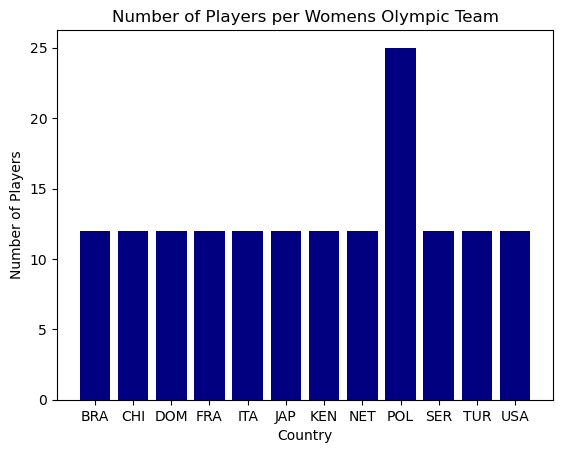

In [159]:
# First Visual
# Number of Players per Olympic Team
V1 = TRS[['Team','JerseyNumber']]
V1 = V1.groupby('Team')
V1 = V1.count()
V1 = V1.reset_index()
# Plot the counts on a bar chart.
plot.bar(x=V1['Team'], height=V1['JerseyNumber'], color='navy')
plot.title("Number of Players per Womens Olympic Team")
plot.xlabel("Country")
plot.ylabel("Number of Players")
plot.show()

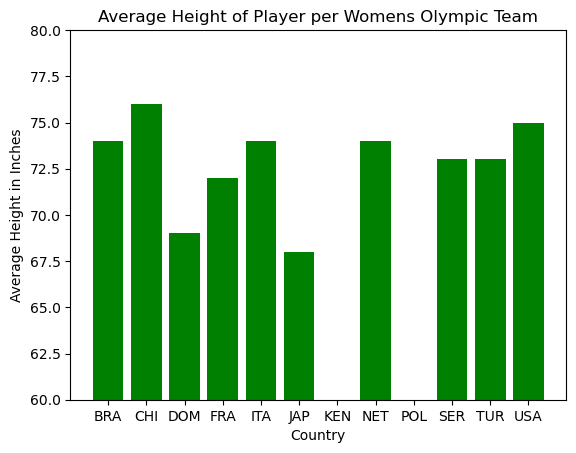

In [161]:
# Second Visual
# Average Height of Player per Olympic Team
V2 = TRSP[['Team','Height (in)']]
V2 = V2.groupby('Team')
V2 = V2['Height (in)'].mean() 
V2 = V2.reset_index()
V2['Height (in)'] = V2['Height (in)'].fillna(0)
V2['Height (in)'] = round(V2['Height (in)'])
# Plot the counts on a bar chart.
plot.bar(x=V2['Team'], height=V2['Height (in)'], color='green')
plot.title("Average Height of Player per Womens Olympic Team")
plt.ylim(60, 80)
plot.xlabel("Country")
plot.ylabel("Average Height in Inches")
plot.show()

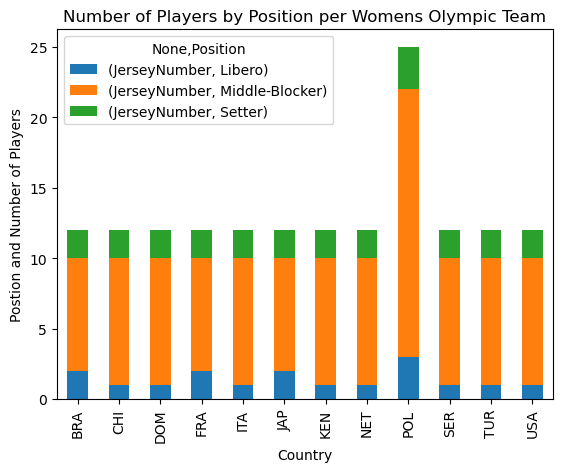

In [163]:
# Third Visual
# Number of Players per Olympic Team by Position
V3 = TRS[['Team','Position','JerseyNumber']]
V3 = V3.groupby(['Team', 'Position']).count()
V3 = V3.unstack('Position')
V3Plot = V3.columns.tolist()
# Plot the counts on a bar chart.
V3[V3Plot].plot(kind ='bar', stacked =True)
plot.title("Number of Players by Position per Womens Olympic Team")
plot.xlabel("Country")
plot.ylabel("Postion and Number of Players")
plot.show()
# The JerseyNumber field was needed for the count, but I couldn't get the legend to update to just the position.

C:\Users\caiti\AppData\Local\Temp\ipykernel_12896\2444214743.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  V4['Matches'] = V4['Matches'].fillna(0)


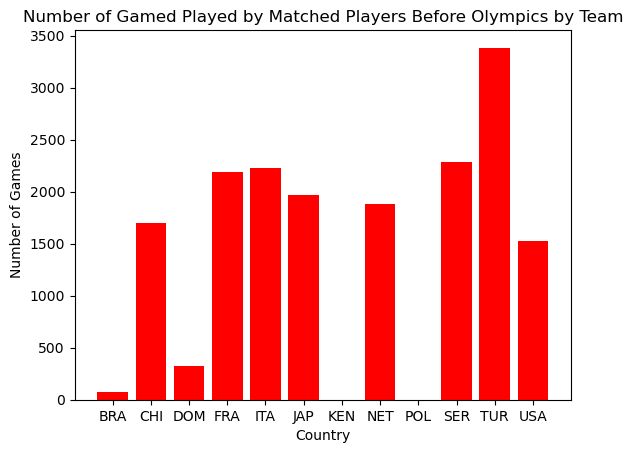

In [165]:
# Fourth Visual
# Number Games Played Before Olympics by Team
V4 = TRSP[['Team','Matches']]
V4['Matches'] = V4['Matches'].fillna(0)
V4 = V4.groupby('Team').sum()
V4 = V4.reset_index()
# Plot the counts on a bar chart.
plot.bar(x=V4['Team'], height=V4['Matches'], color='red')
plot.title("Number of Gamed Played by Matched Players Before Olympics by Team")
plot.xlabel("Country")
plot.ylabel("Number of Games")
plot.show()

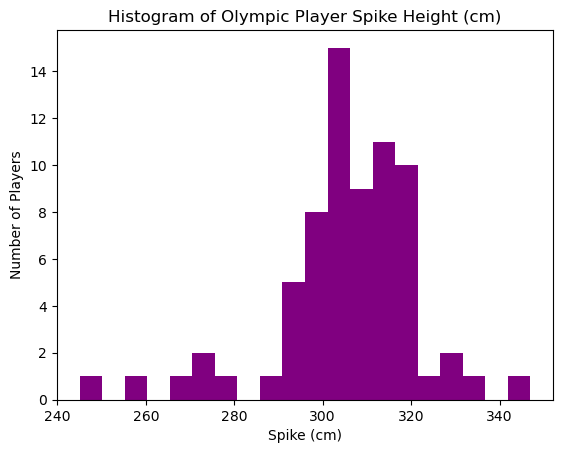

In [167]:
# Fifth Visual
# Histogram of players by spike height
V5 = TRSP[['Spike (cm)']]
V5 = V5.rename(columns={'Spike (cm)': 'Spike'})
V5['Spike'] = V5['Spike'].fillna(0)
V5 = V5.drop(V5[V5['Spike'] == 0].index)
# Plot the values in a histogram
plot.hist(V5.Spike, bins=20, color='purple')
plot.title('Histogram of Olympic Player Spike Height (cm)')
plot.xlabel('Spike (cm)')
plot.ylabel('Number of Players')
plot.show()

DSC 540 Project Summary – Olympic Women’s Volleyball Team and Player Analysis

During the course of this project I learned a lot, including more coding in python, connecting to APIs and websites for data, and the necessity for finding the right data for analysis.  

The first data set was a list of a women volleyball players.  The issue with this data set was that it was updated by the general public.  This caused some duplication and errors within the data itself.  Additionally, the structure of the data field (especially name) was not in the ideal number of columns for connecting to other tables.  To be able to join I had to write a transformation to attempt to put first and last name in their own fields.  
The second data set was retrieved from a website that touted itself as a conduit for driving the commercial success of volleyball.  While an accurate source for retrieving team rosters, there was inconsistent formatting in the name field as well.  Sometimes they included a first initial (sometimes it at the beginning of the field, sometimes at the end).  The limitation of only have a first initial in some cases made joining to the player data very difficult.

The third data set was retrieved via API for the results of the teams during the Olympics.  In this case it was the team name that needed to be modified.  The team name (or Country) wasn’t in a field by itself.  Also, if you wanted to look at whole team performance you had to modify the data set to have a row for each team for a game rather than one.  That way you could add up the performance if it was a home versus away team.

After all the transformations and using SQL to merge the modified tables in a database, I wish I would have found better data sets.  There were some cases where the data may have been available in a different format (like a website) but I already had a website to pull data from.  Wikipedia has a web page for each Olympic team which includes their roster, but I needed an API source.  I think this also is true of any data wrangling assignment, even in the real world.  You need to pick the best data based on what is in the data set and the capabilities of it to merge with other data.

As far as ethical implications, all of this data was publicly available.  Based on my bias to knowing English as my first language, it may have been very difficult for me to match some of the non-USA team player names based on the unique characters used in their language.   Other than that, I believe there were no other ethical implications other than those I dictated during the other milestones.  
